# **MEF Metric Calculator - Individual**
## *Pangeo Access and Reprojection*
This script produces a netcdf file that includes the MEF metric data for the defined model.<br>
Model data is accessed through Pangeo then preprocesssed through xmip and reprojected using xesmf.<br>
The MEF metric is then calculated accordingly and saved to a file.

### 1. Import all relevant packages

In [1]:
import os;  os.chdir('/Users/crcarver/Desktop/AOS_THESIS/MSc_Cameron/Data/')
import warnings
import copy
import matplotlib.pyplot as plt
import xarray as xr
import xesmf as xe
from clisops.core.subset import subset_bbox  # For subsetting
import numpy as np
import matplotlib.colors as mcolors
from mpl_toolkits.basemap import Basemap
import intake
from xmip.preprocessing import combined_preprocessing
from xmip.utils import google_cmip_col
from xmip.postprocessing import match_metrics

### 2. Import Reference Dataset
Import the ancillary file of the observational data. <br>
Data Access https://nsidc.org/data/g02202/versions/4 <br>
Ancilliary File: https://noaadata.apps.nsidc.org/NOAA/G02202_V4/ancillary/<br>
Provides the reference grid of which model data will be reprojected onto.

Define landmask from ancillary file

In [2]:
access_ref_data = 'OBSERVATIONS/SICONC/G02202-cdr-ancillary-sh.nc'
ref_ds = xr.open_dataset(access_ref_data)

mask = xr.where(ref_ds.landmask > 0, float('nan'), 1)

### 3. Import Observational Data
Import the monthly observational data. <br>
Data Access https://nsidc.org/data/g02202/versions/4 <br>
Monthly Data https://noaadata.apps.nsidc.org/NOAA/G02202_V4/south/monthly/ <br>
Monthyl data was combined into a single NetCDF file along the time dimension.
#### Comparing model data to this data will be used to generate the MEF metric.
The data is sliced to a 36 year period of 1979-2009. <br>
All flagged values are masked out.<br>
Observational values of less than 15 are removed.<br>
Any instances where ice is observed for <= 20 occurances throughout the 432 months are masked out. <br>

The temporal mean is defined for all points on the grid.

In [ ]:
access_obs_data='OBSERVATIONS/SICONC/seaice_conc_monthly_sh_n07_v04r00_all.nc' #access combined monthly observational mean data from NSIDC
obs_ds = xr.open_dataset(access_obs_data)                   # Open dataset
obs_ds = obs_ds.sel(tdim=slice('1978-12','2014-11'))  # Time slice of data
obs_da = obs_ds.cdr_seaice_conc_monthly                     # Select desired variable

obs_da = obs_da.where(obs_da <= 2.51, other=float('nan'))   # Set all flagged values to nan
count = obs_da.where(obs_da>0).count('tdim') # Count number of measurements present at each given point over entire time series
mincount = xr.where(count <= 20, float('nan'), 1) #Identify at which points less than 20 observational datapoints exist
obs_da = obs_da * mincount # If less than 20 obs then mask out
o_mean = obs_da.mean(dim='tdim')       # Temporal mean of observational product

### *Variations*

In [3]:
# obs_da = obs_da.where(obs_da > 0.15, other=float('nan'))                    # Exclude (-inf,15]          L15
# obs_da = obs_da.where(obs_da == 0, other=float('nan'))                      # Only values = 0%           ZERO
# obs_da = obs_da.where((obs_da > 0) & (obs_da <= 0.15), other=float('nan'))  # Only values = 0-15%        I015
# obs_da = obs_da.where((obs_da > 0.15) & (obs_da <= 0.8), other=float('nan'))# Only values = 15-80%       I1580
# obs_da = obs_da.where((obs_da > 0.80) & (obs_da <= 1), other=float('nan'))  # only values = 80-100%      I80100

### 4a. Define all CMIP models of interest

In [4]:
# Historical CMIP Models
mods = [
'GFDL-CM4',        #GOOD
 # 'IPSL-CM6A-LR',      #CRASH X
 'MIROC6',         #GOOD
 'SAM0-UNICON',    #GOOD
 'CanESM5',        #GOOD
 'MPI-ESM-1-2-HAM',#GOOD
 'NESM3',          #GOOD
 'CAMS-CSM1-0',    #GOOD
 # 'MPI-ESM1-2-HR',     #CRASH 
 'MPI-ESM1-2-LR',  #GOOD
 'GFDL-ESM4',      #GOOD
 'NorESM2-LM',     #GOOD
 'MRI-ESM2-0',     #GOOD* double lat/lon warning
 'FGOALS-f3-L',    #GOOD* lat/lon warning w/xmip
 'NorESM2-MM',     #GOOD
 'FIO-ESM-2-0',    #GOOD
 'BCC-CSM2-MR',    #GOOD
 'BCC-ESM1',       #GOOD
 'CMCC-CM2-SR5',   #GOOD
 # 'EC-Earth3-AerChem',  #CRASH
 'TaiESM1',        #GOOD
 'NorCPM1',        #GOOD
 # 'IPSL-CM5A2-INCA',   #CRASH X
 'ACCESS-ESM1-5',  #GOOD
 'ACCESS-CM2',     #GOOD
 # 'CMCC-CM2-HR4',      #CRASH X
 # 'EC-Earth3',         #CRASH X
 # 'EC-Earth3-Veg-LR',  #CRASH
 # 'EC-Earth3-Veg',     #NOT IN CAT1
 'CAS-ESM2-0',      #GOOD
 'FGOALS-g3',       #GOOD
 # 'EC-Earth3-CC',      #CRASH
 'CMCC-ESM2',       #GOOD
 # 'IPSL-CM6A-LR-INCA'  #CRASH
]

### 4b. Define all HighResMIP models of interest

In [5]:
# # # # HighResMIP Models CAT1
# mods = [
#     'CMCC-CM2-HR4',    #GOOD !! SICONC on 1-100 scale 
#     'CMCC-CM2-VHR4',   #GOOD !! SICONC on 1-100 scale 
#     'HadGEM3-GC31-HM', #GOOD
#     'HadGEM3-GC31-LL', #GOOD
#     'HadGEM3-GC31-MM', #GOOD
#     # 'CESM1-CAM5-SE-HR', #failed to load
#     # 'CESM1-CAM5-SE-LR', #failed to load
#     # 'HadGEM3-GC31-HH', #CRASH
#     'GFDL-CM4C192', ]  #GOOD

In [6]:
# # HighResMIP Models CAT2
# mods = [
#     'ECMWF-IFS-HR',    #incorrect time format
#     'ECMWF-IFS-LR',    #incorrect time format
#     'ECMWF-IFS-MR',    #incorrect time format
#     'MPI-ESM1-2-HR',   #CRASH
#     'MPI-ESM1-2-XR' ]  #CRASH


In [7]:
# # HighResMIP Models Non in any CAT
# mods = [
#     'AWI-CM-1-1-HR', #Not in CAT1/2/3
#     'BCC-CSM2-HR',   #Not in CAT1/2/3
#     'CNRM-CM6-1-HR', #Not in CAT1/2/3
#     'CNRM-CM6-1',    #Not in CAT1/2/3
#     'EC-Earth3P-HR', #Not in CAT1/2/3
#     'EC-Earth3P', ]  #Not in CAT1/2/3


### 5. Define Pangeo Catalog to call

In [8]:
# Define Pangeo Catalog to call
# uncomment/comment lines to swap catalogs
# url = "https://storage.googleapis.com/cmip6/cmip6-pgf-ingestion-test/catalog/catalog.json" # Only stores that pass current tests
# url = "https://storage.googleapis.com/cmip6/cmip6-pgf-ingestion-test/catalog/catalog_noqc.json" # Only stores that fail current tests
# url = "https://storage.googleapis.com/cmip6/cmip6-pgf-ingestion-test/catalog/catalog_retracted.json" # Only stores that have been retracted by ESGF
# cmip6 = intake.open_esm_datastore(url)
cmip6 = google_cmip_col()

### 6. Call list of models from catalog

In [9]:
# get the list of CMIP6 historical simulations with variable siconc
cat = cmip6.search(
    source_id=mods[16],   # !!Individual Model Selection!!
    variable_id='siconc',
    table_id='SImon',
    experiment_id='historical',
    # activity_id='HighResMIP',
    member_id='r1i1p1f1',
    grid_label='gn'
)
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,CMIP,CMCC,CMCC-CM2-SR5,historical,r1i1p1f1,SImon,siconc,gn,gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5/histor...,NaN,20200616


 ### 7. Preprocess all called models
 Preprocesesed with xMIP - https://cmip6-preprocessing.readthedocs.io/en/latest/?badge=latest

In [10]:
ddict = cat.to_dataset_dict(
    preprocess=combined_preprocessing,
    xarray_open_kwargs={'use_cftime':True})


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


### 8. List all models that have been preprocessed

In [11]:
# list of preprocessed models
mlist = list(ddict.keys())
print(mlist)

['CMIP.CMCC.CMCC-CM2-SR5.historical.SImon.gn']


### 9. Import Model Data
Slice to defined 40 year period 1978-2014

In [12]:
# %% Import Model Data (SOURCE)
model_ds = ddict[mlist[0]]
# model_ds = model_ds.sel(time=slice('1979-01-01','2009-12-31'))  # Time slice of data
model_ds = model_ds.sel(time=slice('1978-12','2014-11'))  # Time slice of data
# model_ds.time.values

# HighResMIP CMCC HR and VHR
# model_ds['siconc'] = model_ds['siconc']/100
model_ds['siconc'] = model_ds['siconc'].where(model_ds['siconc'] <= 100, other=float('nan'))   # Set all flagged values to nan

# Squeeze extraneous variables
dims_to_keep = ['time', 'y', 'x','vertex','bnds']  # Dimensions to be kept
model_ds = model_ds.squeeze(dim=[dim for dim in model_ds.dims if dim not in dims_to_keep])
model_ds

<xarray.Dataset> Size: 193MB
Dimensions:         (time: 432, x: 291, y: 360, vertex: 4, bnds: 2)
Coordinates: (12/13)
    lat             (x, y) float64 838kB dask.array<chunksize=(291, 360), meta=np.ndarray>
    lon             (x, y) float64 838kB dask.array<chunksize=(291, 360), meta=np.ndarray>
  * time            (time) object 3kB 1978-12-16 12:00:00 ... 2014-11-16 00:0...
    type            |S7 7B b'sea_ice'
    lat_verticies   (x, y, vertex) float64 3MB dask.array<chunksize=(291, 360, 4), meta=np.ndarray>
    lon_verticies   (x, y, vertex) float64 3MB dask.array<chunksize=(291, 360, 4), meta=np.ndarray>
    ...              ...
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 284 285 286 287 288 289 290
  * y               (y) int64 3kB 0 1 2 3 4 5 6 ... 353 354 355 356 357 358 359
    lon_bounds      (bnds, x, y) float64 2MB dask.array<chunksize=(1, 291, 360), meta=np.ndarray>
    lat_bounds      (bnds, x, y) float64 2MB dask.array<chunksize=(1, 291, 360), meta=np.ndarray>
    member_id       <U8 32B 'r1i1p1f1'
    dcpp_init_year  float64 8B nan
Dimensions without coordinates: vertex, bnds
Data variables:
    siconc          (time, x, y) float32 181MB dask.array<chunksize=(432, 291, 360), meta=np.ndarray>
Attributes: (12/64)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             0.0
    branch_time_in_parent:            0.0
    cmor_version:                     3.5.0
    ...                               ...
    intake_esm_attrs:variable_id:     siconc
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:zstore:          gs://cmip6/CMIP6/CMIP/CMCC/CMCC-CM2-SR5...
    intake_esm_attrs:version:         20200616
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.CMCC.CMCC-CM2-SR5.historical.SImon.gn

### 10. Define plot details and model name

In [13]:
cmap = plt.get_cmap("magma") ## Reduce
cmap.set_bad("lightgrey")

name = mlist[0].split('.')
model = name[2]
model

'CMCC-CM2-SR5'

### 11. Plot model native grid and siconc

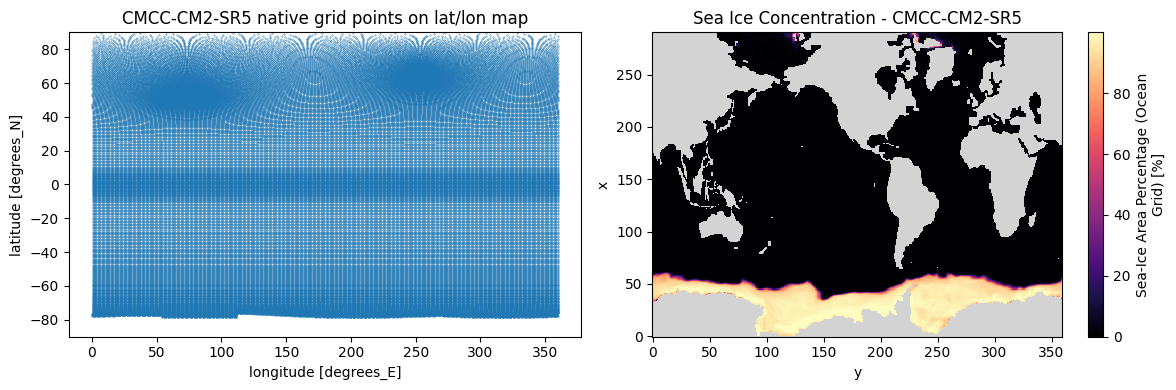

In [14]:
# %% INPUT - MODEL
# Let's look at the grid shape itself and the data for one time step
fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

axs[0].scatter(x=model_ds.lon.values, y=model_ds.lat.values, s=0.1)
axs[0].set_title(f'{model} native grid points on lat/lon map')
axs[0].set_ylim(-90, 90)
axs[0].set_ylabel(f"latitude [{model_ds.lat.units}]")
axs[0].set_xlabel(f"longitude [{model_ds.lon.units}]")
model_ds.siconc.isel(time=8).plot(ax=axs[1], cmap=cmap , vmin=0)
axs[1].set_title(f'Sea Ice Concentration - {model}')
# axs[1].set_ylim(0, 90)
fig.tight_layout()

### 12. Reproject with xESMF
Reproject onto reference grid using xESMF (https://pavics-sdi.readthedocs.io/en/latest/notebooks/regridding.html) <br>

In [15]:
# %% TARGET - REFERENCE
# Visualization of input data and its corresponding grid
bbox = dict(lon_bnds=[-180, 180], lat_bnds=[-80, -50])
ds_tgt = subset_bbox(ref_ds, **bbox)

reg_bil = xe.Regridder(model_ds, ds_tgt, "bilinear", periodic=True,)
# reg_bil  # Show information about the regridding

warnings.filterwarnings("ignore", category=FutureWarning)

# Apply the regridding weights to the input sea ice concentration data
sic_bil = reg_bil(model_ds.siconc) # Can be applied to all variables as needed
model_rp = xr.Dataset({"siconc": sic_bil})

### 13. Overlay land mask 
From observational ancillary file

In [16]:
tct = model_rp.coords['time'].size
for i in range(0,tct,1):
    model_rp.siconc[i,:,:] = model_rp.siconc[i,:,:]*mask

### 14. Align time coordinates
Write time dimension of observational data onto model data

In [17]:
model_ds = model_rp.assign_coords(time=obs_ds['time'])  # Set time coords of model ds to be the same as the obs ds
model_ds = model_ds.swap_dims({'tdim': 'time'})
model_ds = model_ds.swap_dims({'time': 'tdim'})

# Check for max >1 
model_da = model_ds.siconc / 100    # Select desired variable and scale to match obs scale of 0-1
# model_name, exp_id = model_ds.model_name, model_ds.exp_id   # Call model name from attributes

### 15. Visualise siconc
Ensure both model and observstional data are on the same scale

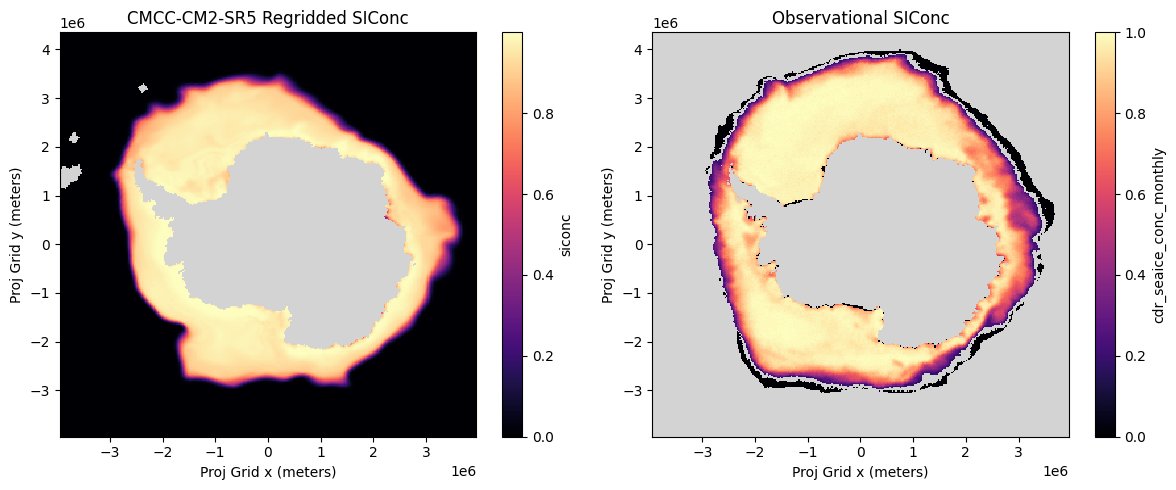

In [18]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

model_da.isel(tdim=8).plot(ax=axs[0], cmap=cmap , vmin=0)
obs_da.isel(tdim=8).plot(ax=axs[1], cmap=cmap , vmin=0)

axs[0].set_title(f'{model} Regridded SIConc')
axs[1].set_title('Observational SIConc')
axs[0].set_ylabel('Proj Grid y (meters)'); axs[0].set_xlabel('Proj Grid x (meters)')
axs[1].set_ylabel('Proj Grid y (meters)'); axs[1].set_xlabel('Proj Grid x (meters)')

fig.tight_layout()

In [19]:
# levels=[0, 0.15, 1]
# colors = ['skyblue', 'royalblue']
# cmap = mcolors.ListedColormap(colors)
# cmap.set_under('white')

# m = Basemap(projection='spstere', boundinglat=-50, lon_0=180, resolution='l')   # Create a Basemap instance with South Polar Stereographic projection
# x, y = m(ref_ds.longitude.values, ref_ds.latitude.values)       # Convert latitude and longitude to map projection coordinates
# m_mean_a = model_da.mean(dim='tdim')

# means = xr.concat([m_mean_a, o_mean], dim='tdim')
# suptitle = ['CMCC-CM2-SR5 SIConc Mean', 'NSIDC Obs Mean']

In [20]:
# # %% SICONC MEAN PLOTTING 
# fig, axes = plt.subplots(1, 2, figsize=(10, 12))

# for i in range(2):
#     ax = axes[i]
#     m = Basemap(projection='spstere', boundinglat=-50, lon_0=180, resolution='l', ax=ax)
#     x, y = m(ref_ds.longitude.values, ref_ds.latitude.values)
#     # plt.clabel(m.contour(x, y, o_mean.values,linestyles='dashed', colors=['limegreen'], levels=[0.15], extend='min'), inline=True, fontsize=8)
#     # plt.clabel(m.contour(x, y, m_mean_a.values, colors=['yellow'], levels=[0.15], extend='min'), inline=True, fontsize=8)
#     contour = m.contourf(x, y, means[i,:,:].values, levels=levels, cmap=cmap, extend='min')
#     m.drawcoastlines()
#     m.drawparallels(np.arange(-90., 0., 10.), labels=[1,0,0,0])
#     m.drawmeridians(np.arange(-180., 181., 30.), labels=[0,0,0,1])
#     ax.set_title(suptitle[i])

# cbar = fig.colorbar(contour, ax=axes.ravel().tolist(), pad=0.05, orientation='horizontal', aspect=50)
# cbar.set_label('Mean SIConc')

### 16. Annual Temporal Mean

In [21]:
MEF_num = (obs_da-model_da) ** 2       # cell-wise RMSD
MEF_num = MEF_num.sum(dim=['tdim'])    # Temporal sum of cell-wise RMSD

MEF_den = (obs_da-o_mean) ** 2         # cell-wise RMSD
MEF_den = MEF_den.sum(dim='tdim')      # Temporal sum of cell-wise SD

MEF_a = (1 - (MEF_num/MEF_den))

### 17. Monthly Temporal Mean

In [24]:
MEF_num = (obs_da-model_da) ** 2        # cell-wise RMSD
MEF_num = MEF_num.groupby('time.month').sum(dim=['tdim'])    # Temporal mean of cell-wise RMSD

MEF_den = (obs_da-o_mean) ** 2          # cell-wise RMSD
MEF_den = MEF_den.groupby('time.month').sum(dim='tdim')      # Temporal mean of cell-wise SD

MEF_m = (1 - (MEF_num/MEF_den))

### 18. Seasonal Temporal Mean

In [25]:
MEF_num = (obs_da-model_da) ** 2        # cell-wise RMSD
MEF_num = MEF_num.groupby('time.season').sum(dim=['tdim'])    # Temporal mean of cell-wise RMSD

MEF_den = (obs_da-o_mean) ** 2          # cell-wise RMSD
MEF_den = MEF_den.groupby('time.season').sum(dim='tdim')      # Temporal mean of cell-wise SD

MEF_s = (1 - (MEF_num/MEF_den))

### 19. Spatial Time Series

In [26]:
MEF_num = (obs_da-model_da) ** 2
MEF_num = MEF_num.sum(dim=['x','y'])

MEF_den = (obs_da-o_mean) ** 2 
MEF_den = MEF_den.sum(dim=['x','y'])

MEF_b = (1 - (MEF_num/MEF_den))

Frozen({'tdim': 432})


### 20. Save each metric to dataset

In [28]:
dataset = xr.Dataset({'MEF_a': MEF_a, 'MEF_s': MEF_s, 'MEF_m': MEF_m, 'MEF_b': MEF_b, 
                      'model_name': model})
dataset

<xarray.Dataset> Size: 21MB
Dimensions:         (x: 316, y: 332, season: 4, month: 12, tdim: 432)
Coordinates:
    xgrid           (x) float32 1kB -3.938e+06 -3.912e+06 ... 3.938e+06
    ygrid           (y) float32 1kB 4.338e+06 4.312e+06 ... -3.938e+06
  * x               (x) float32 1kB -3.938e+06 -3.912e+06 ... 3.938e+06
  * y               (y) float32 1kB 4.338e+06 4.312e+06 ... -3.938e+06
    type            |S7 7B b'sea_ice'
    member_id       <U8 32B 'r1i1p1f1'
    dcpp_init_year  float64 8B nan
    crs             int32 4B -2147483647
  * season          (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * month           (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    time            (tdim) datetime64[ns] 3kB 1978-12-01 ... 2014-11-01
  * tdim            (tdim) datetime64[ns] 3kB 1978-12-01 ... 2014-11-01
Data variables:
    MEF_a           (y, x) float64 839kB dask.array<chunksize=(332, 316), meta=np.ndarray>
    MEF_s           (season, y, x) float64 3MB dask.array<chunksize=(4, 332, 316), meta=np.ndarray>
    MEF_m           (month, y, x) float64 10MB dask.array<chunksize=(12, 332, 316), meta=np.ndarray>
    MEF_b           (tdim) float64 3kB dask.array<chunksize=(432,), meta=np.ndarray>
    m_mean_a        (y, x) float32 420kB dask.array<chunksize=(332, 316), meta=np.ndarray>
    m_mean_s        (season, y, x) float32 2MB dask.array<chunksize=(4, 332, 316), meta=np.ndarray>
    m_mean_m        (month, y, x) float32 5MB dask.array<chunksize=(12, 332, 316), meta=np.ndarray>
    model_name      <U12 48B 'CMCC-CM2-SR5'

### 22. Export dataset to netCDF

In [29]:
# dataset.to_netcdf(f'CMIP-MEF/{model}-MEF-M1LE15.nc')
# dataset.to_netcdf(f'HRMIP-MEF/{model}-MEF.nc')